# Zadanie 1

In [2]:
import time
from functools import update_wrapper

class TimerDecorator:
    def __init__(self, func=None, *, print_each_call=False, max_history=None):
        self.print_each_call = print_each_call
        self.max_history = max_history
        
        self.history = []
        
        self.total_calls = 0

        if func is not None:
            self.func = func
            update_wrapper(self, func) # Zachowanie metadanych oryginalnej funkcji
        else:
            self.func = None

    def __call__(self, *args, **kwargs):
        # Jeśli dekorator został użyty z argumentami
        if self.func is None:
            func = args[0]
            self.func = func
            update_wrapper(self, func)
            return self

        # Pomiar czasu wykonania funkcji
        start_time = time.perf_counter()
        result = self.func(*args, **kwargs)
        end_time = time.perf_counter()

        delta_time = end_time - start_time
        
        # Zapis do historii
        self.history.append(delta_time)
        self.total_calls += 1

        # Ograniczenie rozmiaru historii do max_history
        if self.max_history is not None:
            self.history = self.history[-self.max_history:]

        if self.print_each_call:
            print(f'[{self.__name__}] Wywołanie zajęło: {delta_time:.6f} s')

        return result

    # Metoda do pobierania statystyk
    def get_stats(self):
        count = len(self.history)
        if count == 0:
            return {
                'name': self.__name__,
                'total_calls': self.total_calls,
                'stored_measurements': 0,
                'min': None,
                'max': None,
                'avg': None
            }
        else:
            return {
                'name': self.__name__,
                'total_calls': self.total_calls,
                'stored_measurements': count,
                'min': min(self.history),
                'max': max(self.history),
                'avg': sum(self.history) / count
            }

    # Metoda do wypisywania statystyk
    def print_stats(self):
        stats = self.get_stats()
        print(f"\nStatystyki dla funkcji: '{stats['name']}'")
        print(f"Całkowita liczba wywołań:   {stats['total_calls']}")
        print(f"Przechowywanych pomiarów:   {stats['stored_measurements']}")
        
        if stats['stored_measurements'] > 0:
            print(f"Najkrótszy czas wykonania:  {stats['min']:.6f} s")
            print(f"Najdłuższy czas wykonania:  {stats['max']:.6f} s")
            print(f"Średni czas wykonania:      {stats['avg']:.6f} s")
        else:
            print('Brak pomiarów.')

    def reset_stats(self):
        self.history.clear()
        self.total_calls = 0

    def get_raw_history(self):
        return list(self.history)

## Testowanie dekoratora

In [3]:
# 1. Funkcja wykonujaca sztucznie opóźnione działanie
@TimerDecorator(print_each_call=True, max_history=3)
def sztuczne_opoznienie(id, czas_oczekiwania):
    """Pobiera dane użytkownika na podstawie jego ID z opóźnieniem."""
    time.sleep(czas_oczekiwania)
    return {'id': id, 'data': 'TBD'}

# 2. Funkcja obliczeniowa (Domyślnie - brak printowania na bieżąco i limitu historii)
@TimerDecorator
def silnia(n):
    """Oblicza silnię z podanej liczby n za pomocą pętli."""
    wynik = 1
    for i in range(1, n + 1):
        wynik *= i
    return wynik

print('Test funkcji sztucznego opóźnienia:')
# Funkcja wywołana 5 razy, więc powinno zapamiętać tylko ostatnie 3
for opoznienie in [0.1, 0.2, 0.1, 0.3, 0.1]:
    sztuczne_opoznienie(2137, opoznienie)
    
sztuczne_opoznienie.print_stats()

print('\nTest funkcji obliczeniowej (silnia):')
for i in range(1000, 10000, 1000):
    silnia(i)
    
silnia.print_stats()

print('\nWypisanie słownika ze statystykami oraz zachowanie metadanych:')
    
stats_dict = silnia.get_stats()
print(f'Wariant C (słownik ze statystykami): {stats_dict}')

print(f"Wariant D (oryginalna nazwa): '{silnia.__name__}'")
print(f"Wariant D (oryginalny docstring): '{silnia.__doc__}'")

Test funkcji sztucznego opóźnienia:
[sztuczne_opoznienie] Wywołanie zajęło: 0.100497 s
[sztuczne_opoznienie] Wywołanie zajęło: 0.200348 s
[sztuczne_opoznienie] Wywołanie zajęło: 0.100235 s
[sztuczne_opoznienie] Wywołanie zajęło: 0.300202 s
[sztuczne_opoznienie] Wywołanie zajęło: 0.100814 s

Statystyki dla funkcji: 'sztuczne_opoznienie'
Całkowita liczba wywołań:   5
Przechowywanych pomiarów:   3
Najkrótszy czas wykonania:  0.100235 s
Najdłuższy czas wykonania:  0.300202 s
Średni czas wykonania:      0.167084 s

Test funkcji obliczeniowej (silnia):

Statystyki dla funkcji: 'silnia'
Całkowita liczba wywołań:   9
Przechowywanych pomiarów:   9
Najkrótszy czas wykonania:  0.000197 s
Najdłuższy czas wykonania:  0.015210 s
Średni czas wykonania:      0.005838 s

Wypisanie słownika ze statystykami oraz zachowanie metadanych:
Wariant C (słownik ze statystykami): {'name': 'silnia', 'total_calls': 9, 'stored_measurements': 9, 'min': 0.0001974999999845295, 'max': 0.015210099999990234, 'avg': 0.0058

# Zadanie 2

In [ ]:
class Temperature:    
    _ABSOLUTE_ZERO_C = -273.15

    def __init__(self, celsius=0.0):
        self.celsius = celsius

    @property
    def celsius(self):
        """Odczyt temperatury w stopniach Celsjusza."""
        return self._celsius

    # Ustawianie temperatury w Celsjuszach ze sprawdzeniem czy > 0K
    @celsius.setter
    def celsius(self, value):
        if value < self._ABSOLUTE_ZERO_C:
            self._celsius = self._ABSOLUTE_ZERO_C
        else:
            self._celsius = float(value)

    # Odczyt i ustawianie temperatury w Fahrenheitach
    @property
    def fahrenheit(self):
        return (self._celsius * 9 / 5) + 32

    # Ustawianie temperatury w Fahrenheitach
    @fahrenheit.setter
    def fahrenheit(self, value):
        self.celsius = (value - 32) * 5 / 9

    # Odczyt i ustawianie temperatury w Kelwinach
    @property
    def kelvin(self):
        return self._celsius - self._ABSOLUTE_ZERO_C

    # Ustawianie temperatury w Kelwinach
    @kelvin.setter
    def kelvin(self, value):
        self.celsius = value + self._ABSOLUTE_ZERO_C
    
    def __str__(self):
        return f'Temperature({self._celsius:.2f}°C)'

    # Sprawdzenie, czy jest lodem
    @property
    def is_freezing(self):
        return self._celsius <= 0

    # Sprawdzenie, czy jest parą wodną
    @property
    def is_boiling(self):
        return self._celsius >= 100

    # Wypisanie stanu skupienia wody
    @property
    def state(self):
        if self._celsius < 0:
            return 'Lód'
        elif self._celsius < 100:
            return 'Ciecz'
        else:
            return 'Para wodna'

    # Tworzenie obiektu Temperature na podstawie stopni Fahrenheita
    @classmethod
    def from_fahrenheit(cls, value):
        celsius_value = (value - 32) * 5 / 9
        return cls(celsius_value)

    # Tworzenie obiektu Temperature na podstawie stopni Kelwina
    @classmethod
    def from_kelvin(cls, value):
        celsius_value = value + cls._ABSOLUTE_ZERO_C
        return cls(celsius_value)

    def __add__(self, other):
        if isinstance(other, Temperature):
            return Temperature(self.celsius + other.celsius)
        return NotImplemented

    def __sub__(self, other):
        if isinstance(other, Temperature):
            return Temperature(self.celsius - other.celsius)
        return NotImplemented

    def __eq__(self, other): # Sprawdzenie równości temperatur

        if isinstance(other, Temperature):
            return round(self.celsius, 2) == round(other.celsius, 2) # Przybliżenie do 2 miejsc po przecinku, bo inaczej się psuło :))
        return False

    def __lt__(self, other): # Porównywanie temperatur
        if isinstance(other, Temperature):
            return self.celsius < other.celsius
        else:
            raise TypeError(f'Nie można porównać Temperature z {type(other)}')

In [37]:
print('Podstawowe testy')
t = Temperature(25)
print(f'Początkowa: {t}')
print(f'Celsjusz:    {t.celsius}')      # 25.0
print(f'Fahrenheit:  {t.fahrenheit}')   # 77.0
print(f'Kelvin:      {t.kelvin:.2f}')       # 298.15

print('\nZmiana z 32 F:')
t.fahrenheit = 32
print(f'Celsjusz:    {t.celsius:.1f}')  # 0.0
print(f'Kelvin:      {t.kelvin:.2f}')   # 273.15

print("\nZmiana z 300 K:")
t.kelvin = 300
print(f'Celsjusz:    {t.celsius:.2f}')  # 26.85
print(f'Fahrenheit:  {t.fahrenheit:.2f}') # 80.33

print('\nTest dla wartości poniżej 0K (-100 K):')
t.kelvin = -100
print(f'Kelvin: {t.kelvin:.2f}') # 0.0

print('\nTesty wymagań dodatkowych:')

# Atrybut do odczytania i stan skupienia wody
t_water = Temperature(-10)
print(f'\nTemperatura:  {t_water}')
print(f'Czy zamarza?  {t_water.is_freezing}')
print(f'Stan wody:    {t_water.state}')

# Temperatura z fahrenheita
t2 = Temperature.from_fahrenheit(68)
print(f'\nStworzona z Fahrenheita (68F): {t2}')

# Dodawanie i porównywanie temperatur
t3 = Temperature(20)
t4 = Temperature.from_fahrenheit(15)
t_sum = t3 + t4
print(f'\nDodawanie (20C + 15C): {t_sum}')
print(f'Czy {t3} jest większe niż {t4}? {t3 > t4}')

Podstawowe testy
Początkowa: Temperature(25.00°C)
Celsjusz:    25.0
Fahrenheit:  77.0
Kelvin:      298.15

Zmiana z 32 F:
Celsjusz:    0.0
Kelvin:      273.15

Zmiana z 300 K:
Celsjusz:    26.85
Fahrenheit:  80.33

Test dla wartości poniżej 0K (-100 K):
Kelvin: 0.00

Testy wymagań dodatkowych:

Temperatura:  Temperature(-10.00°C)
Czy zamarza?  True
Stan wody:    Lód

Stworzona z Fahrenheita (68F): Temperature(20.00°C)

Dodawanie (20C + 15C): Temperature(10.56°C)
Czy Temperature(20.00°C) jest większe niż Temperature(-9.44°C)? True


# Zadanie 3

In [ ]:
import matplotlib.pyplot as plt

def lcg(seed, a, c, m, N, as_float = False): #as_float = True - zwraca liczby z przedziału [0, 1)
    """
    Liniowy generator kongruencyjny (LCG)
    """
    x = seed
    for _ in range(N):
        x = (a * x + c) % m     # Wzór: x_n+1 = (a * x_n + c) % m
        
        if as_float:
            yield x / m
        else:
            yield x

In [ ]:
seed = 1
a = 5
c = 3
m = 16
N = 10

print('Ręczne pobieranie wartości za pomocą next():')
gen_manual = lcg(seed, a, c, m, N)
    
print(f"Pierwsza liczba: {next(gen_manual)}")  # 8
print(f"Druga liczba:    {next(gen_manual)}")  # 11
print(f"Trzecia liczba:  {next(gen_manual)}")  # 10
    
    
print('\nUżycie pętli for:')
gen_loop = lcg(seed, a, c, m, 5)
    
print('5 pierwszych liczb całkowitych:')
for liczba in gen_loop:
    print(liczba, end=" ")
    
print('\n\nLiczby zmiennoprzecinkowe [0, 1):')
gen_float = lcg(seed, a, c, m, 5, as_float=True)
    
for liczba in gen_float:
    print(f'{liczba:.4f}')

Ręczne pobieranie wartości za pomocą next():
Pierwsza liczba: 8
Druga liczba:    11
Trzecia liczba:  10

Użycie pętli for:
5 pierwszych liczb całkowitych:
8 11 10 5 12 

Liczby zmiennoprzecinkowe [0, 1):
0.5000
0.6875
0.6250
0.3125
0.7500


## Wykres kolejnych par generowanych przez generator LCG


Analiza generatora LCG na wykresie:


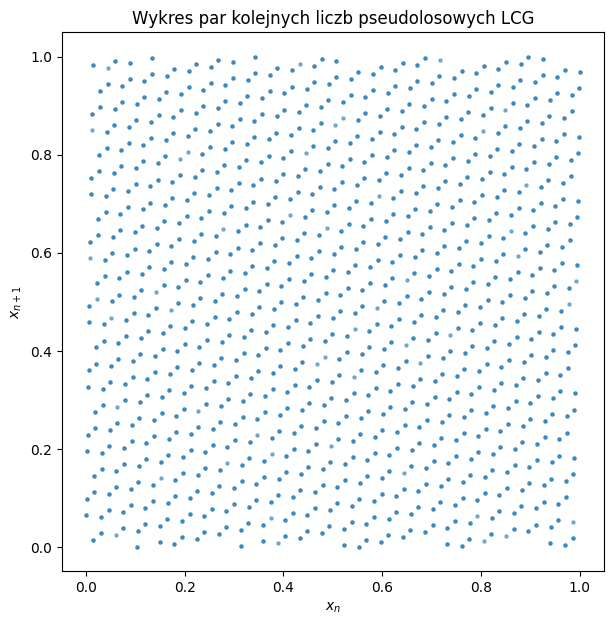

In [ ]:
print('\nAnaliza generatora LCG na wykresie:')

# m_plot = 2**31 - 1
# a_plot = 1103515245
# c_plot = 12345

m_plot = 2048
a_plot = 67
c_plot = 1

values = list(lcg(seed=123, a=a_plot, c=c_plot, m=m_plot, N=2000, as_float=True))

# Tworzenie par (x_n, x_n+1) do wykresu
x_coords = values[:-1] # Od pierwszej do przedostatniej
y_coords = values[1:]  # Od drugiej do ostatniej

plt.figure(figsize=(7, 7))
plt.scatter(x_coords, y_coords, alpha=0.5, s=5)
plt.title('Wykres par kolejnych liczb pseudolosowych LCG')
plt.xlabel('$x_n$')
plt.ylabel('$x_{n+1}$')
plt.show()